## Summary:

This notebook evaluates the interpretability of the encoder by analyzing how different physical Hamiltonian terms contribute to the learned latent representation. It calculates the Jacobian matrix of the encoder to measure sensitivity toward specific input features—density, nearest-neighbor correlations, and on-site interactions—quantifying their relative importance across varying system sizes $L$.

## Requirements:

- You need to have generated or saved ham-terms instances 
- You need to have trained or saved models for system sizes ```L=[4,6,8,10,12,14]```



In [1]:
from dftqml.autoencoders.ae import load_model
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import h5py
from tqdm import tqdm
from torch.func import vmap, jacrev
from dftqml.autoencoders import autoencoder_utils


plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "font.size": 8,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.4,
        "ytick.major.width": 0.4,
        "xtick.major.size": 2,
        "ytick.major.size": 2,
        "axes.labelsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 8,
    }
)

/home/felix/vscode/DFTQML-private/src/dftqml/autoencoders/ae.py:719: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f"Latent Norm Loss ($\lambda_n={lambda_latent_norm}$)")
/home/felix/vscode/DFTQML-private/src/dftqml/autoencoders/ae.py:728: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f"Latent Repulsion Loss ($\lambda_r={lambda_latent_repulsion}$)")
/home/felix/vscode/DFTQML-private/src/dftqml/autoencoders/ae.py:737: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f"Lipschitz Loss Encoder ($\lambda_e={lambda_lipschitz_encoder}$)")
/home/felix/vscode/DFTQML-private/src/dftqml/autoencoders/ae.py:745: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f"Lipschitz Loss Decoder ($\lambda_d={lambda_lipschitz_decoder}$)")


# Interpreting the Encoder Mapping

In [ ]:
# Placeholder for final aggregated results
# Structure: final_stats[L]['mean'] -> [rel_dens, rel_nn, rel_on]
final_stats = {} 

L_values = [4, 6, 8, 10, 12, 14]
input_type = "ham_terms"
latent_diff = -1

for L in tqdm(L_values, desc="Processing System Sizes"):
    # z = L - 1
    
    # Storage for the 3 iterations for THIS L
    # We will store the mean vector [r_d, r_nn, r_on] for each iteration here.
    iter_means = [] 
    
    for i in range(3):
        # ---------------------------------------------------------
        # 1. SETUP & LOAD
        # ---------------------------------------------------------
        
        checkpoint_kwargs = dict(
            models_dir="../models/bs256",
            input_type=input_type,
            L=L,
            N=L,
            U=4.0,
            interpolation="geometric",
            enable_batchnorm=False,
            hidden_depth=4,
            latent_dim=L + latent_diff,
            min_dim=L**2,
            scaling_factor=20.0 if input_type == "ham_terms" else 1.0,
            weight_decay=None,
            lambda_latent_norm=1e-7,
            lambda_latent_repulsion=1e-7,
            lambda_lipschitz_encoder=1e-9,
            lambda_lipschitz_decoder=1e-8,
            iteration=i,
            linear_encoder=False,
            augment_by_symmetry=True
            )

        checkpoint_dir = autoencoder_utils.checkpoint_dir_path(**checkpoint_kwargs)
        
        # Load model and set to eval
        model = load_model(checkpoint_dir, device="cpu")
        model.eval()
        
        device = next(model.parameters()).device
        dtype = next(model.parameters()).dtype    
        
        # Get scaling factor for physical units (18,) -> reshaped for broadcasting later
        # We need this to correct the Jacobian units
        scale_factor = model.input_std.detach().cpu().numpy() 
        
        # ---------------------------------------------------------
        # 2. DATA LOADING
        # ---------------------------------------------------------
        ndata = 10000
        data_path = f"../data/L{L}-N{L}-U4.0_reduced.hdf5"
        with h5py.File(data_path, "r") as f:
            # Load raw data
            data = torch.tensor(f["hamiltonian_terms"][-ndata:].reshape(-1, 3*L),
                                device=device, dtype=dtype)

        # Normalize inputs for the network
        x_flat = model._flatten_input(data)
        x_norm = model._normalize(x_flat)
        x_norm.requires_grad_(True)
        
        # ---------------------------------------------------------
        # 3. COMPUTE JACOBIAN (VECTORIZED)
        # ---------------------------------------------------------
        def encoder_func(vec_1d: torch.Tensor) -> torch.Tensor:
            return model.encoder(vec_1d.unsqueeze(0)).squeeze(0)

        # Compute J for all 10k samples at once
        # Shape: (Batch, Latent, Inputs) -> (10000, z, 3*L)
        batch_jacobian_func = vmap(jacrev(encoder_func))
        J_norm = batch_jacobian_func(x_norm).detach().cpu().numpy()

        # ---------------------------------------------------------
        # 4. PHYSICAL SCALING & SLICING
        # ---------------------------------------------------------
        # Convert gradients to physical units: J_phys = J_norm / sigma
        # Broadcast division over the last dimension (inputs)
        J_phys = J_norm #/ scale_factor[None, None, :]
        
        # Slice into blocks
        # Shape of blocks: (10000, z, L)
        j_density = J_phys[:, :, :L]
        j_nn_corr = J_phys[:, :, L : 2*L]
        j_onsite  = J_phys[:, :, 2*L :]
        
        # ---------------------------------------------------------
        # 5. COMPUTE RELATIVE NORMS
        # ---------------------------------------------------------
        # Calculate Frobenius norm of the matrices for each sample
        # axis=(1,2) collapses (Latent, Inputs) into a single scalar per sample
        n_d = np.linalg.norm(j_density, ord="fro", axis=(1, 2)) # Shape (10000,)
        n_nn = np.linalg.norm(j_nn_corr, ord="fro", axis=(1, 2))
        n_on = np.linalg.norm(j_onsite, ord="fro", axis=(1, 2))
        
        # Stack to shape (10000, 3)
        norms_stacked = np.stack([n_d, n_nn, n_on], axis=1)
        
        # Calculate relative importance per sample
        # Sum across the 3 block types
        total_norms = np.sum(norms_stacked, axis=1, keepdims=True)
        
        # Avoid div by zero
        ratios = norms_stacked / (total_norms + 1e-12) # Shape (10000, 3)
        
        # Take the mean over the 10,000 samples for this iteration
        # This gives us the vector [avg_rel_dens, avg_rel_nn, avg_rel_on] for this model
        iter_mean_vector = np.mean(ratios, axis=0)
        iter_means.append(iter_mean_vector)

    # ---------------------------------------------------------
    # 6. AGGREGATE OVER 3 ITERATIONS
    # ---------------------------------------------------------
    # iter_means is a list of 3 arrays. Convert to (3, 3)
    iter_means_arr = np.array(iter_means)
    
    final_stats[L] = {
        "mean": np.mean(iter_means_arr, axis=0), # The final avg over 3 models
        "std": np.std(iter_means_arr, axis=0)    # The final std over 3 models
    }

Processing System Sizes:   0%|          | 0/6 [00:00<?, ?it/s]

(tensor(4.1051, grad_fn=<SumBackward0>), tensor(3.5917, grad_fn=<SumBackward0>))


Processing System Sizes:  17%|█▋        | 1/6 [00:00<00:02,  1.82it/s]

(tensor(4.0433, grad_fn=<SumBackward0>), tensor(3.5805, grad_fn=<SumBackward0>))
(tensor(4.0637, grad_fn=<SumBackward0>), tensor(3.5521, grad_fn=<SumBackward0>))
(tensor(4.6241, grad_fn=<SumBackward0>), tensor(4.1756, grad_fn=<SumBackward0>))
(tensor(4.6359, grad_fn=<SumBackward0>), tensor(4.1245, grad_fn=<SumBackward0>))


Processing System Sizes:  33%|███▎      | 2/6 [00:00<00:01,  2.48it/s]

...

Processing System Sizes:  67%|██████▋   | 4/6 [00:02<00:01,  1.34it/s]

(tensor(5.5141, grad_fn=<SumBackward0>), tensor(5.1188, grad_fn=<SumBackward0>))
(tensor(5.5604, grad_fn=<SumBackward0>), tensor(5.0961, grad_fn=<SumBackward0>))
(tensor(5.5087, grad_fn=<SumBackward0>), tensor(5.0969, grad_fn=<SumBackward0>))


Processing System Sizes:  83%|████████▎ | 5/6 [00:04<00:01,  1.10s/it]

(tensor(5.7321, grad_fn=<SumBackward0>), tensor(5.3490, grad_fn=<SumBackward0>))
(tensor(5.7191, grad_fn=<SumBackward0>), tensor(5.3348, grad_fn=<SumBackward0>))
(tensor(5.7129, grad_fn=<SumBackward0>), tensor(5.3002, grad_fn=<SumBackward0>))


Processing System Sizes: 100%|██████████| 6/6 [00:07<00:00,  1.18s/it]


In [ ]:
L = 6

checkpoint_kwargs = dict(
    models_dir="../models/bs256",
    input_type=input_type,
    L=L,
    N=L,
    U=4.0,
    interpolation="geometric",
    enable_batchnorm=False,
    hidden_depth=4,
    latent_dim=L + latent_diff,
    min_dim=L**2,
    scaling_factor=20.0 if input_type == "ham_terms" else 1.0,
    weight_decay=None,
    lambda_latent_norm=1e-7,
    lambda_latent_repulsion=1e-7,
    lambda_lipschitz_encoder=1e-9,
    lambda_lipschitz_decoder=1e-8,
    iteration=0,
    linear_encoder=False,
    augment_by_symmetry=True
    )

checkpoint_dir = autoencoder_utils.checkpoint_dir_path(**checkpoint_kwargs)

model = load_model(checkpoint_dir, device="cpu") 

# Ensure eval mode and use the same device/dtype as the model
model.eval()
device = next(model.parameters()).device
dtype = next(model.parameters()).dtype

# Define a function mapping R^D -> R^latent for autograd.functional.jacobian
# Use a 1D vector input and add batch dim inside to keep Jacobian shape [latent, D]
def encoder_func(vec_1d: torch.Tensor) -> torch.Tensor:
    return model.encoder(vec_1d.unsqueeze(0)).squeeze(0)

ndata = 10000

data_path = f"../data/L{L}-N{L}-U4.0_reduced.hdf5"
with h5py.File(data_path, "r") as f:
    data = torch.tensor(f["hamiltonian_terms"][-ndata:].reshape(-1, 3*L),
                        device=device, dtype=dtype)

x_flat = model._flatten_input(data)
x_norm = model._normalize(x_flat)

batch_jacobian_func = vmap(jacrev(encoder_func))

all_jacobians = batch_jacobian_func(x_norm).detach().cpu().numpy()

mean_jacobian_6 = np.mean(all_jacobians, axis=0) # Shape: (z, 3*L)
std_jacobian_6 = np.std(all_jacobians, axis=0)   # Shape: (z, 3*L)

(tensor(4.6506, grad_fn=<SumBackward0>), tensor(4.1566, grad_fn=<SumBackward0>))


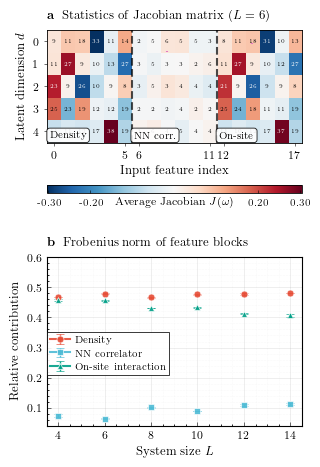

In [4]:
def plot_weight_analysis(
        J_mean_6,
        J_std_6,
        results_dict
        ):
    """
    Create a 2-panel plot analyzing encoder weights.

    Parameters
    ----------
    weight_dict : dict
        Full weight matrices for each L
    spin_summed_density_dict : dict
        Density component weights for each L
    spin_summed_nearest_neighbor_pair_correlators_dict : dict
        NN correlator component weights for each L
    on_site_interaction_dict : dict
        On-site interaction component weights for each L

    Returns
    -------
    fig : matplotlib.figure.Figure
        The figure object
    """
    # Create figure with GridSpec for better control
    fig = plt.figure(figsize=(3.5, 4.5))
    gs = GridSpec(
        2,
        1,
        height_ratios=[1, 1],
        hspace=0.35,
        left=0.15,
        right=0.88,
        bottom=0.08,
        top=0.96,
    )

    # Panel A: Weight matrix heatmap for L=6
    ax1 = fig.add_subplot(gs[0])
    L = 6
    
    # Use raw weights
    vmax = np.abs(J_mean_6).max()

    im = ax1.imshow(
        J_mean_6,
        cmap="RdBu_r",
        aspect="auto",
        vmin=-vmax,
        vmax=vmax,
        interpolation="nearest",
    )
    
    for i in range(J_mean_6.shape[0]):
        for j in range(J_mean_6.shape[1]):
            
            value_std = J_std_6[i,j]*10**(3)
            
            # if value_std != 0:
            if J_mean_6[i,j] > 0.2 or J_mean_6[i,j] < -0.2:
                text = ax1.text(j, i, f"{int(value_std)}",
                            ha="center", va="center", 
                            color="white", fontsize=4)
            else:
                text = ax1.text(j, i, f"{int(value_std)}",
                        ha="center", va="center", 
                        color="black", fontsize=4)
            

    # Add vertical lines to separate components
    ax1.axvline(L - 0.5, color="black", linewidth=1.5, linestyle="--", alpha=0.7)
    ax1.axvline(2 * L - 0.5, color="black", linewidth=1.5, linestyle="--", alpha=0.7)

    # Labels and title
    ax1.set_xlabel(r"Input feature index", fontsize=9)
    ax1.set_ylabel(r"Latent dimension $d$", fontsize=9)
    ax1.set_title(r"\textbf{a}~~Statistics of Jacobian matrix ($L=6$)", fontsize=9, loc="left", pad=8)

    

    # Add text labels inside the plot with white background boxes
    bbox_props = dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="black",
        linewidth=0.6,
        alpha=0.9,
    )
    
    y_pos = J_mean_6.shape[0] - 0.82  # Near top of plot

    ax1.text(
        L / 2 - 1.98,
        y_pos,
        r"Density",
        ha="center",
        va="center",
        fontsize=7,
        bbox=bbox_props,
        zorder=4
    )
    ax1.text(
        L + L / 2 - 1.86,
        y_pos,
        r"NN corr.",
        ha="center",
        va="center",
        fontsize=7,
        bbox=bbox_props,
        zorder=4
    )
    ax1.text(
        2 * L + L / 2 - 2.11,
        y_pos,
        r"On-site",
        ha="center",
        va="center",
        fontsize=7,
        bbox=bbox_props,
        zorder=4
    )

    # Create horizontal colorbar below the figure
    cbar = fig.colorbar(
        im,
        ax=ax1,
        orientation="horizontal",
        fraction=0.08,
        pad=0.25,  # Reduced padding
        aspect=30,
        shrink=1.0,
    )

    # Configure colorbar appearance
    cbar.ax.tick_params(labelsize=7, width=0.4, length=2, direction="in")
    cbar.outline.set_linewidth(0.6)

    # Create ticks at edges and quarters, but skip the middle one
    tick_positions = [-0.3, -0.2, 0.0, 0.2, 0.3]
    tick_labels = [f"{val:.2f}" for val in tick_positions]

    # Set ticks, excluding the middle position
    cbar.set_ticks(
        [tick_positions[0], tick_positions[1], tick_positions[3], tick_positions[4]]
    )
    cbar.set_ticklabels(
        [tick_labels[0], tick_labels[1], tick_labels[3], tick_labels[4]]
    )

    # Position label in the middle where tick is omitted \partial E_{\\boldsymbol{\\theta}}( \\boldsymbol{\\omega})/\\partial \\boldsymbol{\\omega}
    cbar.set_label(r"Average Jacobian $J(\boldmath{\omega})$", fontsize=8, labelpad=-7.25)

    # Adjust label position to be at same level as tick labels
    label = cbar.ax.xaxis.label
    label.set_verticalalignment("top")
    label.set_horizontalalignment("center")


    ax1.tick_params(labelsize=8)
    # ax1.set_xticks(np.arange(17, step=4))
    ax1.set_xticks([0,5,6,11,12,17])

    #################################################
    # Panel B: Component importance vs system size
    ax2 = fig.add_subplot(gs[1])

    L_values = [4,6,8,10,12,14]

    # Nature-style colors
    color_density = "#E64B35"
    color_nn = "#4DBBD5"
    color_onsite = "#00A087"



    for k,v in final_stats.items():
        for i in range(3):
            ax1.errorbar(k,[v["mean"][i]], yerr=v["std"][i])

    for L, sub_dict in results_dict.items():

        # Density
        # mean, std = results_dict[L]["density"]
        ax2.errorbar(
            L,
            sub_dict["mean"][0],
            yerr=sub_dict["std"][0],
            fmt="-o",
            color=color_density,
            markersize=5,
            markeredgewidth=0.5,
            markeredgecolor="white",
            elinewidth=1,
            capsize=3,
            alpha=0.9,
            label="Density" if L == L_values[0] else None,
        )

        # NN correlator
        # mean, std = results_dict[L]["nn_corr"]
        ax2.errorbar(
            L,
            sub_dict["mean"][1],
            yerr=sub_dict["std"][2],
            fmt="-s",
            color=color_nn,
            markersize=5,
            markeredgewidth=0.5,
            markeredgecolor="white",
            elinewidth=1,
            capsize=3,
            alpha=0.9,
            label="NN correlator" if L == L_values[0] else None,
        )

        # On-site
        # mean, std = results_dict[L]["onsite"]
        ax2.errorbar(
            L,
            sub_dict["mean"][2],
            yerr=sub_dict["std"][2],
            fmt="-^",
            color=color_onsite,
            markersize=5,
            markeredgewidth=0.5,
            markeredgecolor="white",
            elinewidth=1,
            capsize=3,
            alpha=0.9,
            label="On-site interaction" if L == L_values[0] else None,
        )


    # Grid
    ax2.grid(True, which="major", linestyle="-", alpha=0.3, linewidth=0.5)
    ax2.grid(True, which="minor", linestyle=":", alpha=0.15, linewidth=0.4)

    # Labels
    ax2.set_xlabel(r"System size $L$", fontsize=9)
    ax2.set_ylabel(r"Relative contribution", fontsize=9)
    ax2.set_title(
        r"\textbf{b}~~Frobenius norm of feature blocks", fontsize=9, loc="left", pad=8
    )

    # Set x-ticks to integer values
    ax2.set_xticks(L_values)

    # Legend
    legend = ax2.legend(
        frameon=True,
        loc=[0,0.3],
        fontsize=7,
        framealpha=0.9,
        edgecolor="black",
        fancybox=False,
        handletextpad=0.5,
    )
    legend.get_frame().set_linewidth(0.6)

    # Tick parameters
    ax2.tick_params(direction="in", which="both", labelsize=8)
    ax2.tick_params(which="major", length=3)
    ax2.tick_params(which="minor", length=1.5)
    ax2.minorticks_on()
    ax2.set_yticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6])

    # Spine customization
    for spine in ax2.spines.values():
        spine.set_linewidth(0.8)

    return fig


fig = plot_weight_analysis(J_mean_6=mean_jacobian_6, J_std_6=std_jacobian_6, results_dict=final_stats)
# fig.savefig("encoder_analysis.pdf", dpi=300, bbox_inches="tight")